In [1]:
import sys,os
sys.path.append(r'X:/Strategies/LeadLagXGB/')
sys.path.append(r'Z:/EnergyTrading/Python/')
sys.path.append(r'Z:/EnergyTrading/Python/Strategies/LeadLagXGB/')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Database.DB_reader import Database
from datetime import date, timedelta

In [3]:
#importing custom library
!pip install git+https://github.com/Vrboska/mofr@master

  Cloning https://github.com/Vrboska/mofr (to revision master) to c:\users\andrej\appdata\local\temp\pip-req-build-u2ejcp_2
  Resolved https://github.com/Vrboska/mofr to commit 3509aedad3ad1469ec00fecd358b78860d8afb6f
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/Vrboska/mofr 'C:\Users\andrej\AppData\Local\Temp\pip-req-build-u2ejcp_2'
  Running command git checkout -b master --track origin/master
  branch 'master' set up to track 'origin/master'.
  Switched to a new branch 'master'


In [4]:
import mofr

# Data Loading

In [5]:
# 1. Read data from source DB
conn = Database('timescaledb')

query=f"""select * from public.dem2_modelling_base""" # where rownum <= 100"""
df=conn.execute(query)


print(f"✅ Loaded {len(df)} rows from source database.")

Connected to the database timescaledb
Disconnected from the database timescaledb
✅ Loaded 1071097 rows from source database.


In [6]:
df=df[df['contract'].apply(lambda x: x in ('dem1', 'dem2', 'deq1', 'dey1'))]
df=df[df['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [7]:
data_orders = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_dem2_orders.csv')

In [8]:
del data_orders['trd_price']
del data_orders['volume']

In [9]:
df['datetime'] = pd.to_datetime(df['datetime'])
data_orders['datetime'] = pd.to_datetime(data_orders['datetime'])

In [10]:
data_orders.head()

,datetime,bid_price,ask_price,mid_price,trd_side
0,2025-01-02 08:00:00.153,82.63,NaN,82.63,NaN
1,2025-01-02 08:00:10.141,82.63,NaN,82.63,NaN
2,2025-01-02 08:00:10.142,82.63,NaN,82.63,NaN
3,2025-01-02 08:02:28.810,91.00,NaN,91.00,NaN
4,2025-01-02 08:05:18.302,92.00,NaN,92.00,NaN


In [11]:
df=pd.merge(df, data_orders, on='datetime', how='outer').sort_values('datetime')

In [12]:
df['bid_price']=df['bid_price'].fillna(method='ffill')
df['ask_price']=df['ask_price'].fillna(method='ffill')
df=df[df['mid_price'].isnull()==True]

df['ba_spread']=df['ask_price']-df['bid_price']
df['mid_price']=(df['ask_price']+df['bid_price'])/2.0

C:\Users\andrej\AppData\Local\Temp\ipykernel_31676\4009137459.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['bid_price']=df['bid_price'].fillna(method='ffill')
C:\Users\andrej\AppData\Local\Temp\ipykernel_31676\4009137459.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ask_price']=df['ask_price'].fillna(method='ffill')


In [13]:
# 1. Add a date column for grouping
df['date'] = df['datetime'].dt.date

# 2. Sort for proper ffill order
df = df.sort_values(['date', 'datetime'])

# 3. Perform forward fill within each date
df = df.groupby('date').apply(lambda g: g.ffill()).reset_index(drop=True)

# 4. (Optional) Drop the helper column if you don't need it anymore
df.drop(columns='date', inplace=True)

C:\Users\andrej\AppData\Local\Temp\ipykernel_31676\1671415354.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('date').apply(lambda g: g.ffill()).reset_index(drop=True)


In [14]:
df.shape

(537167, 73)

In [15]:
df.head()

,datetime,tradeid,contract,trd_price,volume,ll_dem1_dem2_macd_12_26,ll_dem1_dem2_macd_18_38,ll_dem1_dem2_macd_30_60,ll_dem1_dem2_macd_6_14,ll_dem1_dem2_vii_3_dem2,...,target_short_dem2_10_trds_3.0_perc,target_short_dem2_10_trds_5.0_perc,target_short_dem2_20_trds_1.0_perc,target_short_dem2_20_trds_3.0_perc,target_short_dem2_20_trds_5.0_perc,bid_price,ask_price,mid_price,trd_side,ba_spread
0,2025-01-02 09:00:55.610597,Eurex T7/DEBQ042025-20250102/849/1,deq1,82,1.0,None,None,None,None,0.14104272325256012,...,None,None,None,None,None,97.77,97.94,97.855,NaN,0.17
1,2025-01-02 09:01:18.449423,Eurex T7/DEBM022025-20250102/858/1,dem1,115.36,1.0,None,None,None,None,0.12700834507624195,...,None,None,None,None,None,97.74,97.86,97.800,NaN,0.12
2,2025-01-02 09:01:18.449423,Eurex T7/DEBM032025-20250102/858/1,dem2,97.86,1.0,-0.009547139113507797,0.020477648453237407,0.05253599082223559,-0.03707778263500927,0.1267962829907468,...,None,None,None,None,None,97.74,97.86,97.800,NaN,0.12
3,2025-01-02 09:01:59.860338,Eurex T7/DEBM022025-20250102/879/1,dem1,115.43,1.0,-0.009547139113507797,0.020477648453237407,0.05253599082223559,-0.03707778263500927,0.10776988706121415,...,None,None,None,None,None,97.73,97.86,97.795,NaN,0.13
4,2025-01-02 09:02:32.845537,Eurex T7/DEBM022025-20250102/890/1,dem1,115.4,1.0,-0.009547139113507797,0.020477648453237407,0.05253599082223559,-0.03707778263500927,0.09653766766836218,...,None,None,None,None,None,97.71,97.84,97.775,NaN,0.13


In [16]:
df.columns

Index(['datetime', 'tradeid', 'contract', 'trd_price', 'volume',
       'll_dem1_dem2_macd_12_26', 'll_dem1_dem2_macd_18_38',
       'll_dem1_dem2_macd_30_60', 'll_dem1_dem2_macd_6_14',
       'll_dem1_dem2_vii_3_dem2', 'll_dem1_dem2_vii_5_dem2',
       'll_dem1_dem2_vii_7_dem2', 'll_dem1_dem2_fair_price',
       'll_deq1_dem2_fair_price', 'll_ttfm1_dem2_fair_price',
       'atr_dem2_candles_10min_lookback_21',
       'atr_dem2_candles_15min_lookback_21', 'atr_dem2_candles_1h_lookback_21',
       'atr_dem2_candles_30min_lookback_21',
       'atr_dem2_candles_5min_lookback_21', 'll_aux_ens_dem2_fair_price',
       'll_aux_ens_dem2_fair_ret', 'obook_a_price_dem2',
       'obook_a_price_sparsity_dem2', 'obook_a_vol_dem2', 'obook_b_price_dem2',
       'obook_b_price_sparsity_dem2', 'obook_b_vol_dem2',
       'obook_ba_spread_dem2', 'obook_ba_volrat_00_dem2',
       'obook_ba_volrat_30_dem2', 'obook_ba_volrat_50_dem2',
       'obook_ba_volrat_90_dem2', 'obook_mid_pricew_00_dem2',
       'ob

In [17]:
df=df.dropna(subset=['ll_aux_ens_dem2_fair_price'])

# Predictor exploration

In [18]:
# Assume df is already loaded and has a datetime column
# Filter out only predictors (not identifiers or price/volume)
exclude = {'datetime', 'tradeid', 'contract', 'trd_price', 'volume'}
predictor_cols = [col for col in df.columns if col not in exclude]

# Calculate null percentage per predictor per month
df['month'] = df['datetime'].dt.to_period('M')
null_pct = df.groupby('month')[predictor_cols].apply(lambda x: x.isnull().mean() * 100)
# Show the full DataFrame without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(null_pct)

,ll_dem1_dem2_macd_12_26,ll_dem1_dem2_macd_18_38,ll_dem1_dem2_macd_30_60,ll_dem1_dem2_macd_6_14,ll_dem1_dem2_vii_3_dem2,ll_dem1_dem2_vii_5_dem2,ll_dem1_dem2_vii_7_dem2,ll_dem1_dem2_fair_price,ll_deq1_dem2_fair_price,ll_ttfm1_dem2_fair_price,atr_dem2_candles_10min_lookback_21,atr_dem2_candles_15min_lookback_21,atr_dem2_candles_1h_lookback_21,atr_dem2_candles_30min_lookback_21,atr_dem2_candles_5min_lookback_21,ll_aux_ens_dem2_fair_price,ll_aux_ens_dem2_fair_ret,obook_a_price_dem2,obook_a_price_sparsity_dem2,obook_a_vol_dem2,obook_b_price_dem2,obook_b_price_sparsity_dem2,obook_b_vol_dem2,obook_ba_spread_dem2,obook_ba_volrat_00_dem2,obook_ba_volrat_30_dem2,obook_ba_volrat_50_dem2,obook_ba_volrat_90_dem2,obook_mid_pricew_00_dem2,obook_mid_pricew_30_dem2,obook_mid_pricew_50_dem2,obook_mid_pricew_90_dem2,obook_mid_pricew_d_00_dem2,obook_mid_pricew_d_30_dem2,obook_mid_pricew_d_50_dem2,obook_mid_pricew_d_90_dem2,obook_mid_price_dem2,swing_high_dem2_candles_10min,swing_high_dem2_candles_15min,swing_high_dem2_candles_1h,swing_high_dem2_candles_30min,swing_high_dem2_candles_5min,swing_low_dem2_candles_10min,swing_low_dem2_candles_15min,swing_low_dem2_candles_1h,swing_low_dem2_candles_30min,swing_low_dem2_candles_5min,vpin_100_dem2,vpin_10_dem2,vpin_20_dem2,vpin_50_dem2,target_long_dem2_10_trds_1.0_perc,target_long_dem2_10_trds_3.0_perc,target_long_dem2_10_trds_5.0_perc,target_long_dem2_20_trds_1.0_perc,target_long_dem2_20_trds_3.0_perc,target_long_dem2_20_trds_5.0_perc,target_short_dem2_10_trds_1.0_perc,target_short_dem2_10_trds_3.0_perc,target_short_dem2_10_trds_5.0_perc,target_short_dem2_20_trds_1.0_perc,target_short_dem2_20_trds_3.0_perc,target_short_dem2_20_trds_5.0_perc,bid_price,ask_price,mid_price,trd_side,ba_spread
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01,0.0,0.0,0.0,0.0,0.000000,0.000871,0.064452,0.408483,2.018900,100.0,0.384967,0.384967,10.410661,0.384967,0.384967,0.0,0.0,1.97361,1.97361,1.97361,1.974481,1.97361,1.974481,1.974481,1.97361,1.97361,1.97361,1.97361,1.974481,1.974481,1.974481,1.974481,1.974481,1.974481,1.974481,1.974481,1.974481,45.960894,50.682402,100.0,100.0,29.564081,46.887602,100.0,100.0,100.0,30.624047,0.566128,0.566128,0.566128,0.566128,53.283108,53.283108,53.283108,53.283108,53.283108,53.283108,53.283108,53.283108,53.283108,53.283108,53.283108,53.283108,0.0,0.0,0.0,100.0,0.0
2025-02,0.0,0.0,0.0,0.0,0.010963,0.201904,0.443092,0.867913,2.716110,100.0,0.070347,0.070347,0.294177,0.070347,0.070347,0.0,0.0,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.564363,79.558369,100.0,100.0,24.801294,34.900144,100.0,100.0,100.0,24.837837,1.449871,1.449871,1.449871,1.449871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,100.0,0.0
2025-03,0.0,0.0,0.0,0.0,0.080831,0.362392,0.530790,1.091218,2.934163,100.0,0.393377,0.393377,9.467998,0.393377,0.596802,0.0,0.0,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,41.936440,100.000000,100.0,100.0,21.743523,43.469533,100.0,100.0,100.0,31.761172,1.654340,1.654340,1.654340,1.654340,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,100.0,0.0
2025-04,0.0,0.0,0.0,0.0,0.170627,0.268128,0.300303,0.579156,2.167448,100.0,0.035100,0.035100,7.780584,0.035100,0.035100,0.0,0.0,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.659994,100.000000,100.0,100.0,47.612687,62.882326,100.0,100.0,100.0,44.873882,1.037411,1.037411,1.037411,1.037411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,

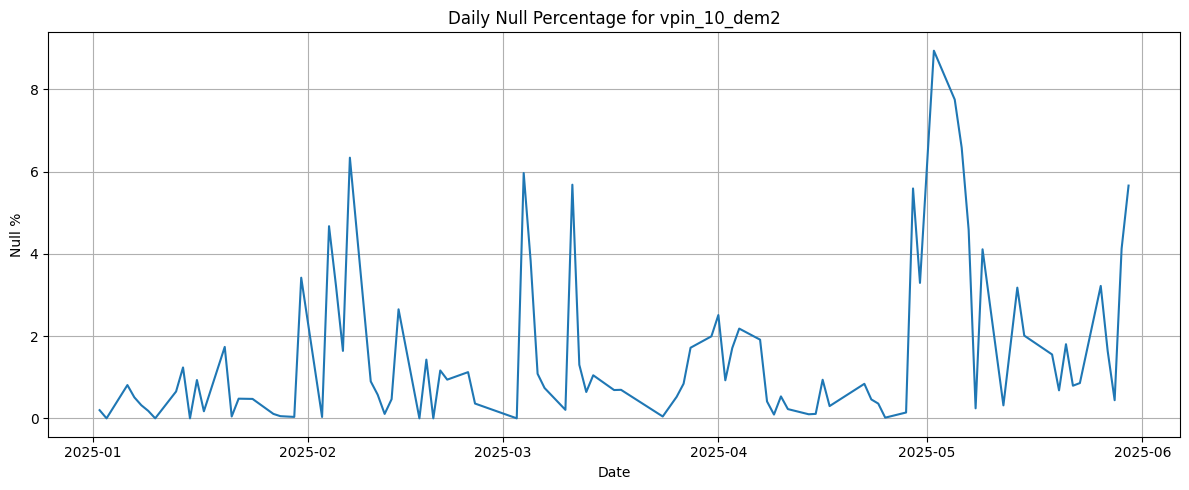

In [19]:

# Replace this with your actual predictor name
predictor = "vpin_10_dem2"

# Ensure datetime is parsed correctly
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract date
df['date'] = df['datetime'].dt.date

# Calculate daily null percentage for the predictor
daily_null_pct = df.groupby('date')[predictor].apply(lambda x: x.isnull().mean() * 100)

# Plot
plt.figure(figsize=(12, 5))
daily_null_pct.plot(title=f'Daily Null Percentage for {predictor}')
plt.ylabel('Null %')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
from decimal import Decimal

# Define a large number to replace infinities
large_number = 1e10

# Replace both positive and negative infinity
df.replace([np.inf, -np.inf], large_number, inplace=True)

df = df.applymap(lambda x: float(x) if isinstance(x, Decimal) else x)

C:\Users\andrej\AppData\Local\Temp\ipykernel_31676\3392917933.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: float(x) if isinstance(x, Decimal) else x)


# Longs

In [21]:
df['ll_dem1_dem2_fair_price_diff_mid']=df['ll_dem1_dem2_fair_price'].astype(float)-df['mid_price'].astype(float)
df['ll_aux_ens_dem2_fair_price_diff_mid']=df['ll_aux_ens_dem2_fair_price'].astype(float)-df['mid_price'].astype(float)

In [22]:
#df_long=df[(df['contract']=='dem2')&(df['trd_price'].apply(float)-df['ask_price']>0.0)]
df_long=df[(df['ll_aux_ens_dem2_fair_price']-df['ask_price']>0.0) & (df['contract']=='dem1')]

In [23]:
target_col='target_long_dem2_10_trds_1.0_perc'
target_col2='target_long_dem2_20_trds_3.0_perc'

feature_cols=[
       'll_dem1_dem2_macd_12_26', 
       'll_dem1_dem2_macd_18_38',
       'll_dem1_dem2_macd_30_60', 
       'll_dem1_dem2_macd_6_14',
       'll_dem1_dem2_vii_3_dem2', 
       'll_dem1_dem2_vii_5_dem2',
       'll_dem1_dem2_vii_7_dem2', 'll_dem1_dem2_fair_price_diff_mid',
       'atr_dem2_candles_10min_lookback_21',
       'atr_dem2_candles_15min_lookback_21', 
       'atr_dem2_candles_1h_lookback_21',
       'atr_dem2_candles_30min_lookback_21',
       'atr_dem2_candles_5min_lookback_21', 
       'll_aux_ens_dem2_fair_price_diff_mid',
       'll_aux_ens_dem2_fair_ret',
        'obook_a_price_sparsity_dem2', 'obook_a_vol_dem2', 
        'obook_b_price_sparsity_dem2', 'obook_b_vol_dem2',
        'obook_ba_spread_dem2', 'obook_ba_volrat_00_dem2',
        'obook_ba_volrat_30_dem2', 'obook_ba_volrat_50_dem2',
        'obook_ba_volrat_90_dem2', 'obook_mid_pricew_d_00_dem2',
        'obook_mid_pricew_d_30_dem2', 'obook_mid_pricew_d_50_dem2',
        'obook_mid_pricew_d_90_dem2', 
       # 'swing_high_dem2_candles_10min', 'swing_high_dem2_candles_15min',
       # 'swing_high_dem2_candles_1h', 'swing_high_dem2_candles_30min',
       # 'swing_high_dem2_candles_5min', 'swing_low_dem2_candles_10min',
       # 'swing_low_dem2_candles_15min', 'swing_low_dem2_candles_1h',
       # 'swing_low_dem2_candles_30min', 'swing_low_dem2_candles_5min',
       'vpin_100_dem2', 
       'vpin_10_dem2', 
       'vpin_20_dem2', 
       'vpin_50_dem2'
       ]

In [24]:
df_long=df_long.dropna(subset=feature_cols+[target_col])

In [25]:
df_long[target_col].value_counts()

target_long_dem2_10_trds_1.0_perc
0.0    25199
1.0    18451
Name: count, dtype: int64

In [26]:
df_long[target_col].value_counts(normalize=True)

target_long_dem2_10_trds_1.0_perc
0.0    0.577297
1.0    0.422703
Name: proportion, dtype: float64

## Univariate predictor analysis

In [27]:
result = []
for feat in feature_cols:
    try:
        print(feat)
        gini = mofr.metrics.gini(df_long[target_col].apply(float), df_long[feat].apply(float))
        result.append((feat, gini))
    except:
        print('problem')

pd.DataFrame(result, columns=["feature", "gini"]).sort_values(by="gini", key=lambda x: x.abs(), ascending=False)

ll_dem1_dem2_macd_12_26
ll_dem1_dem2_macd_18_38
ll_dem1_dem2_macd_30_60
ll_dem1_dem2_macd_6_14
ll_dem1_dem2_vii_3_dem2
ll_dem1_dem2_vii_5_dem2
ll_dem1_dem2_vii_7_dem2
ll_dem1_dem2_fair_price_diff_mid
atr_dem2_candles_10min_lookback_21
atr_dem2_candles_15min_lookback_21
atr_dem2_candles_1h_lookback_21
atr_dem2_candles_30min_lookback_21
atr_dem2_candles_5min_lookback_21
ll_aux_ens_dem2_fair_price_diff_mid
ll_aux_ens_dem2_fair_ret
obook_a_price_sparsity_dem2
obook_a_vol_dem2
obook_b_price_sparsity_dem2
obook_b_vol_dem2
obook_ba_spread_dem2
obook_ba_volrat_00_dem2
obook_ba_volrat_30_dem2
obook_ba_volrat_50_dem2
obook_ba_volrat_90_dem2
obook_mid_pricew_d_00_dem2
obook_mid_pricew_d_30_dem2
obook_mid_pricew_d_50_dem2
obook_mid_pricew_d_90_dem2
vpin_100_dem2
vpin_10_dem2
vpin_20_dem2
vpin_50_dem2


,feature,gini
14,ll_aux_ens_dem2_fair_ret,0.104905
3,ll_dem1_dem2_macd_6_14,-0.101826
15,obook_a_price_sparsity_dem2,0.092112
21,obook_ba_volrat_30_dem2,0.082586
6,ll_dem1_dem2_vii_7_dem2,-0.074390
20,obook_ba_volrat_00_dem2,0.069802
19,obook_ba_spread_dem2,0.069630
5,ll_dem1_dem2_vii_5_dem2,-0.067507
30,vpin_20_dem2,0.067224
24,obook_mid_pricew_d_00_dem2,-0.064394


In [28]:
# Calculate monthly gini for ll_aux_ens_dem2_fair_price_diff_mid
df_long['month'] = df_long['datetime'].dt.month
monthly_gini = []

for month in sorted(df_long['month'].unique()):
    month_mask = df_long['month'] == month
    month_data = df_long[month_mask]
    
    gini = mofr.metrics.gini(
        month_data[target_col].apply(float), 
        month_data['ll_aux_ens_dem2_fair_price_diff_mid'].apply(float)
    )
    
    monthly_gini.append({
        'month': month,
        'gini': gini
    })

gini_df = pd.DataFrame(monthly_gini)
print('Monthly Gini Coefficients for ll_aux_ens_dem2_fair_price_diff_mid:')
display(gini_df)

# Calculate overall gini for reference
overall_gini = mofr.metrics.gini(
    df_long[target_col].apply(float), 
    df_long['ll_aux_ens_dem2_fair_price_diff_mid'].apply(float)
)
print(f'\nOverall Gini: {overall_gini:.4f}')

Monthly Gini Coefficients for ll_aux_ens_dem2_fair_price_diff_mid:


,month,gini
0,1,0.111862
1,2,-0.028646
2,3,0.054537
3,4,0.019589
4,5,0.058080



Overall Gini: 0.0500


## XGB model

In [29]:
# --- Month-based XGBoost model training and evaluation for LONGS ---
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import calendar

# Prepare date column
if 'date' not in df_long.columns:
    df_long['date'] = df_long['datetime'].dt.date
if 'month' not in df_long.columns:
    df_long['month'] = pd.to_datetime(df_long['date']).dt.to_period('M')

unique_months = sorted(df_long['month'].unique())

all_predictions = []
all_actual_values = []
all_probabilities = []
all_dates = []

for i, month in enumerate(unique_months):
    # Use all data before the current month for training
    train_months = unique_months[:i]
    if len(train_months) == 0:
        continue
    train_mask = df_long['month'].isin(train_months)
    test_mask = df_long['month'] == month
    X_train = df_long.loc[train_mask, feature_cols]
    y_train = df_long.loc[train_mask, target_col]
    X_test = df_long.loc[test_mask, feature_cols]
    y_test = df_long.loc[test_mask, target_col]
    test_dates = df_long.loc[test_mask, 'date']
    if len(X_test) == 0 or len(X_train) == 0:
        continue
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1
    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    all_predictions.extend(y_pred)
    all_actual_values.extend(y_test)
    all_probabilities.extend(y_pred_proba)
    all_dates.extend(list(test_dates))

results_df_long = pd.DataFrame({
    'date': all_dates,
    'actual': all_actual_values,
    'predicted': all_predictions,
    'probability': all_probabilities
})

results_df_long['month'] = pd.to_datetime(results_df_long['date']).dt.month
monthly_metrics = []
for month in sorted(results_df_long['month'].unique()):
    month_mask = results_df_long['month'] == month
    month_data = results_df_long[month_mask]
    lift = mofr.metrics.lift(month_data['actual'], month_data['probability'])
    gini = mofr.metrics.gini(month_data['actual'].apply(int), month_data['probability'])
    sorted_data = month_data.sort_values('probability', ascending=False)
    top_50 = sorted_data.head(50)
    precision_top_50 = top_50['actual'].mean() if len(top_50) == 50 else None
    monthly_metrics.append({
        'month': month,
        'lift': lift,
        'gini': gini,
        'precision_top_50': precision_top_50
    })
metrics_df_long = pd.DataFrame(monthly_metrics)
print('Monthly Performance Metrics (Longs):')
display(metrics_df_long)

print('\nOverall Performance Metrics (Longs):')
if len(results_df_long) == 0:
    print('No predictions available for overall metrics.')
else:
    print('Lift:', mofr.metrics.lift(results_df_long['actual'], results_df_long['probability']))
    print('Gini:', mofr.metrics.gini(results_df_long['actual'].apply(int), results_df_long['probability']))
    sorted_overall = results_df_long.sort_values('probability', ascending=False)
    top_50_overall = sorted_overall.head(50)
    precision_top_50_overall = top_50_overall['actual'].mean() if len(top_50_overall) == 50 else None
    print(f'Precision (top 50): {precision_top_50_overall:.4f}' if precision_top_50_overall is not None else "N/A")

Monthly Performance Metrics (Longs):


,month,lift,gini,precision_top_50
0,2,1.186372,0.089882,0.42
1,3,1.216283,0.171958,0.56
2,4,1.415542,0.147964,0.42
3,5,1.396495,0.250609,0.92



Overall Performance Metrics (Longs):
Lift: 1.2478447309065959
Gini: 0.13077161770564039
Precision (top 50): 0.4800


In [30]:
results_df_long[results_df_long['month']==5].groupby('probability').agg(count=('probability', 'size'), mean_target=('actual', 'mean')).sort_index(ascending=False).head(20)


,count,mean_target
probability,,
0.917274,2,1.0
0.914823,1,0.0
0.914728,1,1.0
0.914106,1,1.0
0.909921,1,1.0
0.907171,2,1.0
0.906912,2,0.0
0.906456,2,1.0
0.904593,3,1.0


# Shorts

In [31]:
df['ll_dem1_dem2_fair_price_diff_mid']=df['ll_dem1_dem2_fair_price']-df['obook_mid_price_dem2']
df['ll_aux_ens_dem2_fair_price_diff_mid']=df['ll_aux_ens_dem2_fair_price']-df['mid_price']

In [32]:
#df_short=df[(df['contract']=='dem2')&(df['bid_price']-df['trd_price'].apply(float)>0.0)]
df_short=df[(-df['ll_aux_ens_dem2_fair_price']+df['bid_price']>0.03) & (df['contract']=='dem1')]

In [33]:
target_col='target_short_dem2_10_trds_1.0_perc'
feature_cols=[
       'll_dem1_dem2_macd_12_26', 
       'll_dem1_dem2_macd_18_38',
       'll_dem1_dem2_macd_30_60', 
       'll_dem1_dem2_macd_6_14',
       'll_dem1_dem2_vii_3_dem2', 
       'll_dem1_dem2_vii_5_dem2',
       'll_dem1_dem2_vii_7_dem2', 'll_dem1_dem2_fair_price_diff_mid',
       'atr_dem2_candles_10min_lookback_21',
       'atr_dem2_candles_15min_lookback_21', 
       'atr_dem2_candles_1h_lookback_21',
       'atr_dem2_candles_30min_lookback_21',
       'atr_dem2_candles_5min_lookback_21', 
       'll_aux_ens_dem2_fair_price_diff_mid',
       'll_aux_ens_dem2_fair_ret',
        'obook_a_price_sparsity_dem2', 'obook_a_vol_dem2', 
        'obook_b_price_sparsity_dem2', 'obook_b_vol_dem2',
        'obook_ba_spread_dem2', 'obook_ba_volrat_00_dem2',
        'obook_ba_volrat_30_dem2', 'obook_ba_volrat_50_dem2',
        'obook_ba_volrat_90_dem2', 'obook_mid_pricew_d_00_dem2',
        'obook_mid_pricew_d_30_dem2', 'obook_mid_pricew_d_50_dem2',
        'obook_mid_pricew_d_90_dem2', 
       # 'swing_high_dem2_candles_10min', 'swing_high_dem2_candles_15min',
       # 'swing_high_dem2_candles_1h', 'swing_high_dem2_candles_30min',
       # 'swing_high_dem2_candles_5min', 'swing_low_dem2_candles_10min',
       # 'swing_low_dem2_candles_15min', 'swing_low_dem2_candles_1h',
       # 'swing_low_dem2_candles_30min', 'swing_low_dem2_candles_5min',
       'vpin_100_dem2', 
       'vpin_10_dem2', 
       'vpin_20_dem2', 
       'vpin_50_dem2'
       ]

In [34]:
df_short=df_short.dropna(subset=feature_cols+[target_col])

In [35]:
df_short[target_col].value_counts()

target_short_dem2_10_trds_1.0_perc
0.0    13228
1.0     9998
Name: count, dtype: int64

In [36]:
df_short[target_col].value_counts(normalize=True)

target_short_dem2_10_trds_1.0_perc
0.0    0.569534
1.0    0.430466
Name: proportion, dtype: float64

## Univariate predictor analysis

In [37]:
result = []
for feat in feature_cols:
    try:
        print(feat)
        gini = mofr.metrics.gini(df_short[target_col].apply(float), df_short[feat].apply(float))
        result.append((feat, gini))
    except:
        print('problem')

pd.DataFrame(result, columns=["feature", "gini"]).sort_values(by="gini", key=lambda x: x.abs(), ascending=False)

ll_dem1_dem2_macd_12_26
ll_dem1_dem2_macd_18_38
ll_dem1_dem2_macd_30_60
ll_dem1_dem2_macd_6_14
ll_dem1_dem2_vii_3_dem2
ll_dem1_dem2_vii_5_dem2
ll_dem1_dem2_vii_7_dem2
ll_dem1_dem2_fair_price_diff_mid
atr_dem2_candles_10min_lookback_21
atr_dem2_candles_15min_lookback_21
atr_dem2_candles_1h_lookback_21
atr_dem2_candles_30min_lookback_21
atr_dem2_candles_5min_lookback_21
ll_aux_ens_dem2_fair_price_diff_mid
ll_aux_ens_dem2_fair_ret
obook_a_price_sparsity_dem2
obook_a_vol_dem2
obook_b_price_sparsity_dem2
obook_b_vol_dem2
obook_ba_spread_dem2
obook_ba_volrat_00_dem2
obook_ba_volrat_30_dem2
obook_ba_volrat_50_dem2
obook_ba_volrat_90_dem2
obook_mid_pricew_d_00_dem2
obook_mid_pricew_d_30_dem2
obook_mid_pricew_d_50_dem2
obook_mid_pricew_d_90_dem2
vpin_100_dem2
vpin_10_dem2
vpin_20_dem2
vpin_50_dem2


,feature,gini
3,ll_dem1_dem2_macd_6_14,0.128711
12,atr_dem2_candles_5min_lookback_21,0.119848
10,atr_dem2_candles_1h_lookback_21,0.116833
8,atr_dem2_candles_10min_lookback_21,0.105113
11,atr_dem2_candles_30min_lookback_21,0.099899
9,atr_dem2_candles_15min_lookback_21,0.085754
0,ll_dem1_dem2_macd_12_26,0.083772
6,ll_dem1_dem2_vii_7_dem2,-0.082136
19,obook_ba_spread_dem2,0.081338
13,ll_aux_ens_dem2_fair_price_diff_mid,-0.075440


## Month-based Logistic Regression Model (Shorts)
This cell implements the month-based model training and evaluation for the shorts strategy. The model is trained on all available data up to the end of each month and used to predict for the following month. Metrics include precision@100, lift, gini, and accuracy, both monthly and overall.

In [38]:
# --- Month-based XGBoost model training and evaluation for SHORTS ---
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import calendar

if 'date' not in df_short.columns:
    df_short['date'] = df_short['datetime'].dt.date
if 'month' not in df_short.columns:
    df_short['month'] = pd.to_datetime(df_short['date']).dt.to_period('M')

unique_months = sorted(df_short['month'].unique())

all_predictions = []
all_actual_values = []
all_probabilities = []
all_dates = []

for i, month in enumerate(unique_months):
    train_months = unique_months[:i]
    if len(train_months) == 0:
        continue
    train_mask = df_short['month'].isin(train_months)
    test_mask = df_short['month'] == month
    X_train = df_short.loc[train_mask, feature_cols]
    y_train = df_short.loc[train_mask, target_col]
    X_test = df_short.loc[test_mask, feature_cols]
    y_test = df_short.loc[test_mask, target_col]
    test_dates = df_short.loc[test_mask, 'date']
    if len(X_test) == 0 or len(X_train) == 0:
        continue
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1
    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    all_predictions.extend(y_pred)
    all_actual_values.extend(y_test)
    all_probabilities.extend(y_pred_proba)
    all_dates.extend(list(test_dates))

results_df_short = pd.DataFrame({
    'date': all_dates,
    'actual': all_actual_values,
    'predicted': all_predictions,
    'probability': all_probabilities
})

results_df_short['month'] = pd.to_datetime(results_df_short['date']).dt.month
monthly_metrics = []
for month in sorted(results_df_short['month'].unique()):
    month_mask = results_df_short['month'] == month
    month_data = results_df_short[month_mask]
    lift = mofr.metrics.lift(month_data['actual'], month_data['probability'])
    gini = mofr.metrics.gini(month_data['actual'].apply(int), month_data['probability'])
    sorted_data = month_data.sort_values('probability', ascending=False)
    top_50 = sorted_data.head(50)
    precision_top_50 = top_50['actual'].mean() if len(top_50) == 50 else None
    monthly_metrics.append({
        'month': month,
        'lift': lift,
        'gini': gini,
        'precision_top_50': precision_top_50
    })
metrics_df_short = pd.DataFrame(monthly_metrics)
print('Monthly Performance Metrics (Shorts):')
display(metrics_df_short)

print('\nOverall Performance Metrics (Shorts):')
if len(results_df_short) == 0:
    print('No predictions available for overall metrics (Shorts).')
else:
    print('Lift:', mofr.metrics.lift(results_df_short['actual'], results_df_short['probability']))
    print('Gini:', mofr.metrics.gini(results_df_short['actual'].apply(int), results_df_short['probability']))
    sorted_overall = results_df_short.sort_values('probability', ascending=False)
    top_50_overall = sorted_overall.head(50)
    precision_top_50_overall = top_50_overall['actual'].mean() if len(top_50_overall) == 50 else None
    print(f'Precision (top 50): {precision_top_50_overall:.4f}' if precision_top_50_overall is not None else "N/A")

Monthly Performance Metrics (Shorts):


,month,lift,gini,precision_top_50
0,2,1.184358,0.146622,0.78
1,3,1.111834,0.177010,0.78
2,4,1.059610,0.213822,0.40
3,5,1.505454,0.052702,0.86



Overall Performance Metrics (Shorts):
Lift: 1.207126135392578
Gini: 0.1663455706136816
Precision (top 50): 0.7800


In [48]:
df_export=pd.concat([df_short[df_short['date'].apply(str)>='2025-02-01'][['datetime', 'tradeid', 'contract']].reset_index(drop=True), results_df_short], axis=1)
df_export['datetime'] = pd.to_datetime(df_export['datetime'])
df_export['tradeid'] = df_export['tradeid'].astype(str)  # or .astype(int) if DB expects int
df_export['contract'] = df_export['contract'].astype(str)
df_export['actual'] = df_export['actual'].astype(float)
df_export['predicted'] = df_export['predicted'].astype(int)
df_export['probability'] = df_export['probability'].astype(float)
df_export['month'] = df_export['month'].astype(int)

print(df_export.dtypes)

conn = Database('timescaledb')
conn._connect()


df_export.to_sql('user_andrej_zubal.dem2_xgb_short_score', conn.engine, index=False, if_exists='append', method='multi', chunksize=1000)

datetime       datetime64[ns]
tradeid                object
contract               object
date                   object
actual                float64
predicted               int32
probability           float64
month                   int32
dtype: object
Connected to the database timescaledb


1

In [49]:
results_df_short[results_df_short['month']==2].groupby('probability').agg(count=('probability', 'size'), mean_target=('actual', 'mean')).sort_index(ascending=False).head(20)


,count,mean_target
probability,,
0.995625,7,1.0
0.995227,1,1.0
0.994794,1,1.0
0.994720,1,1.0
0.994328,4,1.0
0.994258,1,1.0
0.993951,1,1.0
0.993935,1,1.0
0.993533,1,0.0


Training long model...


[15:40:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

[15:40:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

[15:40:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


Overall accuracy (long): 0.6961

Training short model...


[15:40:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

[15:40:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
[15:40:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-au

Overall accuracy (short): 0.6743


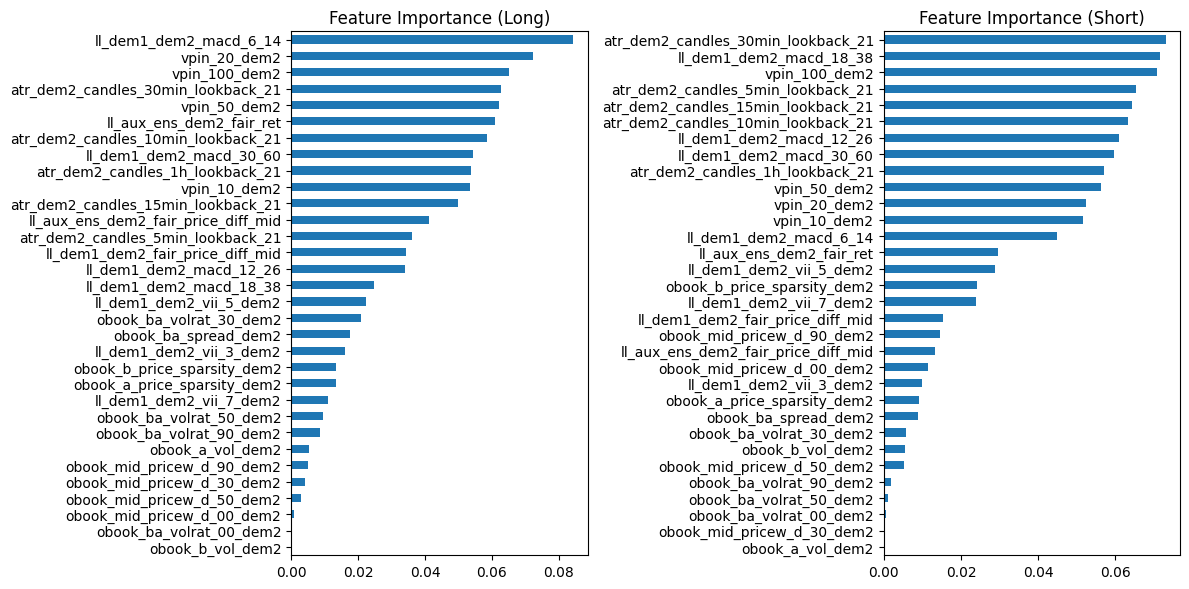

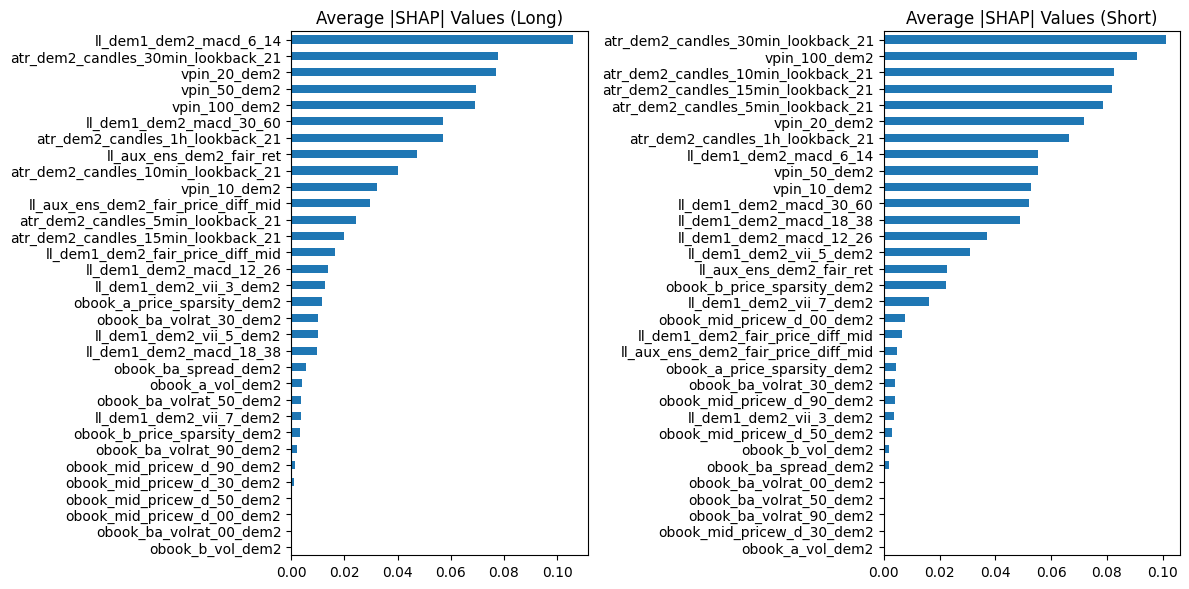


Top 5 Most Important Features (Long):
ll_dem1_dem2_macd_6_14                0.084391
vpin_20_dem2                          0.072411
vpin_100_dem2                         0.065178
atr_dem2_candles_30min_lookback_21    0.062718
vpin_50_dem2                          0.062070
dtype: float32

Top 5 Most Important Features (Short):
atr_dem2_candles_30min_lookback_21    0.073063
ll_dem1_dem2_macd_18_38               0.071492
vpin_100_dem2                         0.070706
atr_dem2_candles_5min_lookback_21     0.065250
atr_dem2_candles_15min_lookback_21    0.064224
dtype: float32


In [41]:
from sklearn.preprocessing import StandardScaler
import shap
import numpy as np
import calendar
import xgboost as xgb
from xgboost import XGBClassifier

# Initialize for both long and short models
df_long['date'] = df_long['datetime'].dt.date
df_short['date'] = df_short['datetime'].dt.date

def train_and_evaluate_model(df, feature_cols, target_col, window_days=14):
    unique_dates = sorted(df['date'].unique())
    all_predictions = []
    all_actual_values = []
    all_probabilities = []
    all_dates = []
    feature_importance_list = []
    shap_values_list = []
    
    # For each date after the initial window
    for i in range(window_days, len(unique_dates)):
        current_date = unique_dates[i]
        
        # Get training data from the rolling window
        train_dates = unique_dates[i-window_days:i]
        train_mask = df['date'].isin(train_dates)
        test_mask = (df['date'] == current_date)
        
        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, target_col]
        X_test = df.loc[test_mask, feature_cols]
        y_test = df.loc[test_mask, target_col]
        
        # Skip if no test data for this date
        if len(X_test) == 0:
            continue
            
        # Train XGBoost model
        model = XGBClassifier(
            max_depth=3,
            learning_rate=0.1,
            n_estimators=10,
            scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # Handle class imbalance
            random_state=42
        )
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        # Store feature importance for this window
        feature_importance_list.append(
            pd.Series(model.feature_importances_, index=feature_cols)
        )
        
        # Calculate SHAP values for feature importance
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):  # For binary classification
            shap_values = shap_values[1]  # Take positive class
        shap_values_list.append(pd.DataFrame(shap_values, columns=feature_cols))
        
        # Store results
        all_predictions.extend(y_pred)
        all_actual_values.extend(y_test)
        all_probabilities.extend(y_pred_proba)
        all_dates.extend([current_date] * len(y_pred))
    
    # Calculate average feature importance across all windows
    avg_feature_importance = pd.concat(feature_importance_list, axis=1).mean(axis=1)
    avg_shap_values = pd.concat(shap_values_list).abs().mean()
    
    return pd.DataFrame({
        'date': all_dates,
        'actual': all_actual_values,
        'predicted': all_predictions,
        'probability': all_probabilities
    }), avg_feature_importance, avg_shap_values

# Train and evaluate long model
print("Training long model...")
results_long, importance_long, shap_long = train_and_evaluate_model(
    df_long, feature_cols, 'target_long_dem2_10_trds_3.0_perc'
)
print(f"Overall accuracy (long): {accuracy_score(results_long['actual'], results_long['predicted']):.4f}")

# Train and evaluate short model
print("\nTraining short model...")
results_short, importance_short, shap_short = train_and_evaluate_model(
    df_short, feature_cols, 'target_short_dem2_10_trds_3.0_perc'
)
print(f"Overall accuracy (short): {accuracy_score(results_short['actual'], results_short['predicted']):.4f}")

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
importance_long.sort_values().plot(kind='barh')
plt.title('Feature Importance (Long)')
plt.tight_layout()

plt.subplot(1, 2, 2)
importance_short.sort_values().plot(kind='barh')
plt.title('Feature Importance (Short)')
plt.tight_layout()
plt.show()

# Plot SHAP values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
shap_long.sort_values().plot(kind='barh')
plt.title('Average |SHAP| Values (Long)')
plt.tight_layout()

plt.subplot(1, 2, 2)
shap_short.sort_values().plot(kind='barh')
plt.title('Average |SHAP| Values (Short)')
plt.tight_layout()
plt.show()

# Print top 5 most important features for each model
print("\nTop 5 Most Important Features (Long):")
print(importance_long.sort_values(ascending=False).head())
print("\nTop 5 Most Important Features (Short):")
print(importance_short.sort_values(ascending=False).head())